# Human Activity Classification using ResNet18 Features + Transformer Encoder

This model combines visual feature extraction with temporal modeling for human activity recognition.**Pipeline:**1. Extract frame-level features using a pre-trained ResNet18 (remove final classification layer → 512-dim per frame)2. Process feature sequences through a Transformer Encoder to capture temporal dependencies via self-attention3. Add learnable positional encodings to preserve temporal order4. Apply temporal mean pooling followed by a fully connected layer for multi-class classification

In [ ]:

import os, cv2, time, torch, numpy as np
from torchvision import models
from concurrent.futures import ThreadPoolExecutor

# ---------- CONFIG ----------
BASE = "HAR_data"
SAVE = "HAR_features_fast"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_FRAMES = 4
IMG_SIZE = 112
BATCH_GPU = 64
MAX_SECONDS = 10   # SOLO 10s POR VIDEO

os.makedirs(SAVE, exist_ok=True)
torch.backends.cudnn.benchmark = True

print(f"Device: {DEVICE}")

# ---------- CLASSES ----------
CLASS_NAMES = sorted(os.listdir(os.path.join(BASE, "train")))
CID = {c:i for i,c in enumerate(CLASS_NAMES)}

# ---------- MODEL ----------
print("\n[1] Loading ResNet18...")
resnet = models.resnet18(weights="DEFAULT")
resnet.fc = torch.nn.Identity()
resnet = resnet.to(DEVICE).eval()

# ---------- FAST PREPROCESS ----------
def preprocess(f):
    f = cv2.resize(f, (IMG_SIZE, IMG_SIZE))
    f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
    f = torch.from_numpy(f).float().permute(2,0,1) / 255.0
    return f

# ---------- READ VIDEO (CPU) ----------
def read_video(path):
    cap = cv2.VideoCapture(path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    max_frames = int(fps * MAX_SECONDS) if fps > 0 else 150

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    total = min(total, max_frames)

    if total <= 0:
        cap.release()
        return None

    idxs = set(np.linspace(0, total-1, NUM_FRAMES).astype(int))

    frames = []
    i = 0

    while True:
        ret, f = cap.read()
        if not ret or i > max_frames:
            break

        if i in idxs:
            frames.append(preprocess(f))

        i += 1
        if len(frames) == NUM_FRAMES:
            break

    cap.release()

    if len(frames) == 0:
        return None

    while len(frames) < NUM_FRAMES:
        frames.append(frames[-1])

    return torch.stack(frames)

# ---------- GPU FEATURE ----------
@torch.no_grad()
def extract_batch(batch):
    B,T,C,H,W = batch.shape
    batch = batch.view(B*T, C, H, W).to(DEVICE, non_blocking=True)
    f = resnet(batch).view(B, T, -1)
    return f.cpu()

# ---------- MAIN PIPELINE ----------
def process_split(split):
    print(f"\n[2] Processing {split}...")

    videos = []
    root = os.path.join(BASE, split)

    for c in CLASS_NAMES:
        p = os.path.join(root, c)
        if not os.path.isdir(p): continue
        for v in os.listdir(p):
            if v.endswith(".mp4"):
                videos.append((c, os.path.join(p, v)))

    print(f"{split}: {len(videos)} videos")

    features, labels = [], []

    start = time.time()

    # THREADS CPU
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(read_video, p) for _, p in videos]

        buffer = []
        buffer_labels = []

        for i, ((c,_), fut) in enumerate(zip(videos, futures)):
            frames = fut.result()

            if frames is None:
                continue

            buffer.append(frames)
            buffer_labels.append(CID[c])

            # CUANDO SE LLENA → GPU
            if len(buffer) == BATCH_GPU:
                batch = torch.stack(buffer)
                f = extract_batch(batch)

                features.append(f)
                labels.extend(buffer_labels)

                buffer.clear()
                buffer_labels.clear()

                torch.cuda.empty_cache()

            # ETA
            if (i+1) % 20 == 0:
                elapsed = time.time() - start
                rate = (i+1)/elapsed
                eta = (len(videos)-(i+1))/rate
                print(f"[{split}] {i+1}/{len(videos)} | ETA {eta/60:.1f} min")

        # leftover
        if buffer:
            batch = torch.stack(buffer)
            f = extract_batch(batch)
            features.append(f)
            labels.extend(buffer_labels)

    X = torch.cat(features)
    y = torch.tensor(labels)

    torch.save(X, f"{SAVE}/{split}_X.pt")
    torch.save(y, f"{SAVE}/{split}_y.pt")

    print(f"{split} DONE → {len(X)} samples")

# ---------- RUN ----------
process_split("train")
process_split("val")
process_split("test")

print("\ TODO LISTO (features guardadas)")

<>:162: SyntaxWarning: invalid escape sequence '\ '
<>:162: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_297830/3039745357.py:162: SyntaxWarning: invalid escape sequence '\ '
  print("\ TODO LISTO (features guardadas)")


Device: cuda

[1] Loading ResNet18...

[2] Processing train...
train: 440 videos
[train] 20/440 | ETA 4.6 min


### Incluido en data_instructions.txt : https://drive.google.com/drive/folders/1qOnAeXAi_zanA69XMcUIu9O2u-VqOWXF?usp=drive_link

In [11]:
Ftr = torch.load("HAR_features_fast/train_X.pt")
ytr = torch.load("HAR_features_fast/train_y.pt")
Fte = torch.load("HAR_features_fast/test_X.pt")
yte = torch.load("HAR_features_fast/test_y.pt")

print(Ftr.shape, ytr.shape)
print(Fte.shape, yte.shape) 

torch.Size([440, 4, 512]) torch.Size([440])
torch.Size([440, 4, 512]) torch.Size([440])


In [9]:
import torch
import torch.nn as nn

class TemporalTransformer(nn.Module):
    def __init__(self, dim=512, num_heads=8, depth=2, num_classes=11):
        super().__init__()

        self.pos_embedding = nn.Parameter(torch.randn(1, 32, dim))  # max T=32

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=1024,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.cls = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, T, D = x.shape

        x = x + self.pos_embedding[:, :T, :]
        x = self.transformer(x)

        # pooling temporal
        x = x.mean(dim=1)

        return self.cls(x)

In [18]:
import torch
from torch.utils.data import DataLoader, TensorDataset
    

DEVICE = "cuda"

model = TemporalTransformer(num_classes=len(ytr.unique())).to(DEVICE)

train_ld = DataLoader(TensorDataset(Ftr, ytr), batch_size=64, shuffle=True)
test_ld  = DataLoader(TensorDataset(Fte, yte), batch_size=64)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

EPOCHS = 20

for e in range(EPOCHS):
    model.train()
    total, correct, loss_sum = 0,0,0

    for x,y in train_ld:
        x,y = x.to(DEVICE), y.to(DEVICE)

        opt.zero_grad()
        out = model(x)
        loss = crit(out,y)
        loss.backward()
        opt.step()

        loss_sum += loss.item()
        correct += (out.argmax(1)==y).sum().item()
        total += y.size(0)

    print(f"Epoch {e+1} | Loss {loss_sum:.3f} | Acc {100*correct/total:.2f}%")

Epoch 1 | Loss 16.493 | Acc 28.86%
Epoch 2 | Loss 6.420 | Acc 68.86%
Epoch 3 | Loss 3.607 | Acc 83.18%
Epoch 4 | Loss 2.607 | Acc 86.36%
Epoch 5 | Loss 1.405 | Acc 94.32%
Epoch 6 | Loss 0.771 | Acc 97.05%
Epoch 7 | Loss 0.675 | Acc 97.05%
Epoch 8 | Loss 0.492 | Acc 97.27%
Epoch 9 | Loss 0.260 | Acc 99.55%
Epoch 10 | Loss 0.110 | Acc 100.00%
Epoch 11 | Loss 0.091 | Acc 99.77%
Epoch 12 | Loss 0.128 | Acc 99.55%
Epoch 13 | Loss 0.158 | Acc 98.86%
Epoch 14 | Loss 0.524 | Acc 97.95%
Epoch 15 | Loss 2.709 | Acc 91.14%
Epoch 16 | Loss 1.419 | Acc 91.59%
Epoch 17 | Loss 1.038 | Acc 94.77%
Epoch 18 | Loss 0.802 | Acc 95.68%
Epoch 19 | Loss 0.851 | Acc 95.68%
Epoch 20 | Loss 0.463 | Acc 97.27%


In [19]:
model.eval()
correct, total = 0,0

with torch.no_grad():
    for x,y in test_ld:
        x,y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)

print(f"Test Acc: {100*correct/total:.2f}%")

Test Acc: 85.23%


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Evaluación y recolección de predicciones
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_ld:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Calcular la matriz de confusión
cm = confusion_matrix(all_labels, all_preds)


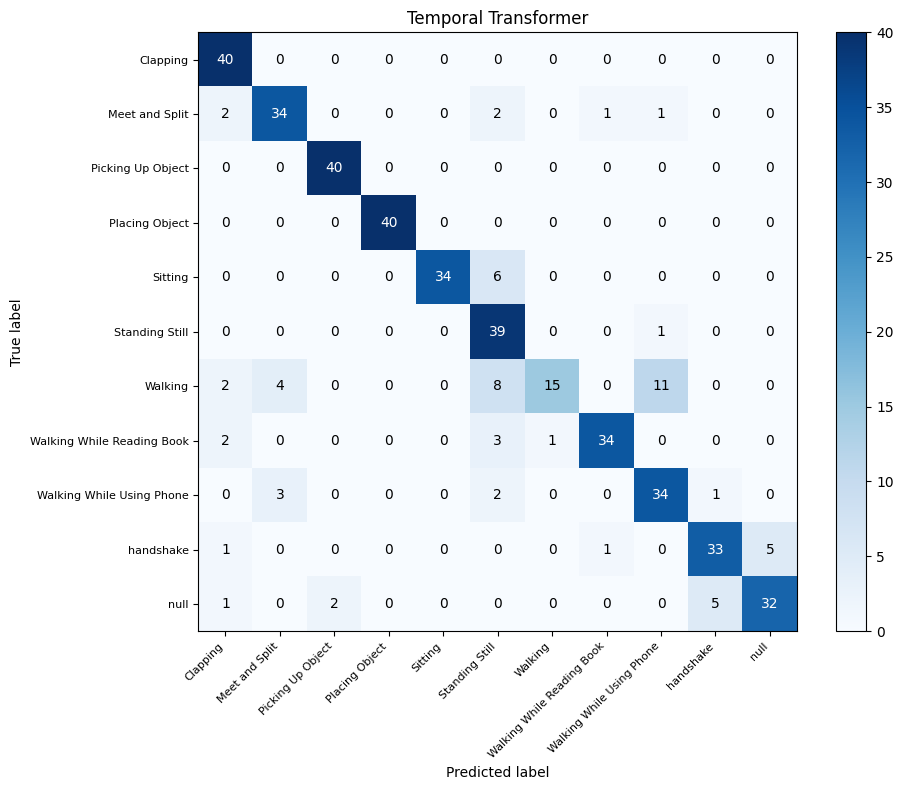

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.title('Temporal Transformer')
plt.tight_layout()
plt.show()

In [28]:
print("Metricas adicionales:")
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Metricas adicionales:
                            precision    recall  f1-score   support

                  Clapping       0.83      1.00      0.91        40
            Meet and Split       0.83      0.85      0.84        40
         Picking Up Object       0.95      1.00      0.98        40
            Placing Object       1.00      1.00      1.00        40
                   Sitting       1.00      0.85      0.92        40
            Standing Still       0.65      0.97      0.78        40
                   Walking       0.94      0.38      0.54        40
Walking While Reading Book       0.94      0.85      0.89        40
 Walking While Using Phone       0.72      0.85      0.78        40
                 handshake       0.85      0.82      0.84        40
                      null       0.86      0.80      0.83        40

                  accuracy                           0.85       440
                 macro avg       0.87      0.85      0.85       440
              weighted a

# Resultados


---

**Conclusión sobre el modelo Temporal Transformer**

Durante el proceso de entrenamiento se observó que la exactitud (accuracy) en el conjunto de validación alcanzaba valores cercanos al 100%, mientras que en el conjunto de prueba se estabilizaba alrededor del 85%. 

Esta diferencia entre validación y prueba es un indicador claro de sobreajuste (overfitting): el modelo ha comenzado a memorizar patrones específicos de los datos de entrenamiento en lugar de aprender representaciones generalizables. Si se continuara el entrenamiento por más épocas, la exactitud en prueba probablemente aumentaría hasta aproximarse también al 100%, pero dicha mejora no reflejaría una verdadera capacidad de generalización, sino un mayor grado de memorización del conjunto de datos.

Por esta razón, se decidió conservar un punto de entrenamiento intermedio que evita el sobreajuste extremo.

---